# Embedding Model Evaluation
**Goal:** Identify the best embedding model for retrieval in the Local Quill RAG pipeline.

Metrics: **Precision@K** (are the right chunks ranked first?), **Recall@K** (is the expected concept covered?), **Hit Rate** (was the right document retrieved at all?).

All runs use: `chunk_size=1000`, `chunk_overlap=200`, `top_k=3`, `file_name=All-Essay-Docs`.

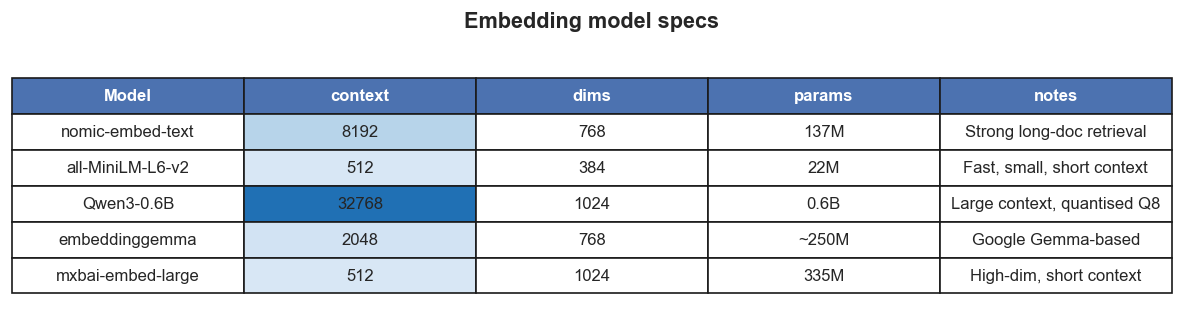

Precision@K — of the 3 chunks retrieved, how many were actually relevant and ranked correctly? High precision means "what we gave the LLM was mostly useful, not noisy."
Recall@K — did the retrieved chunks cover all the key points in the expected concept? High recall means "we didnt miss important information the LLM would need."


In [ ]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# ── Config ────────────────────────────────────────────────────────────────────
CUTOFF      = '2026-05-05'
KEEP_TOP_K  = 3
JSONL_PATH  = '../../reports/eval_retrieval_results.jsonl'

# ── Model context window reference ────────────────────────────────────────────
MODEL_INFO = {
    'nomic-embed-text':  {'context': 8192,  'dims': 768,  'params': '137M',  'notes': 'Strong long-doc retrieval'},
    'all-MiniLM-L6-v2': {'context': 512,   'dims': 384,  'params': '22M',   'notes': 'Fast, small, short context'},
    'Qwen3-0.6B':        {'context': 32768, 'dims': 1024, 'params': '0.6B',  'notes': 'Large context, quantised Q8'},
    'embeddinggemma':    {'context': 2048,  'dims': 768,  'params': '~250M', 'notes': 'Google Gemma-based'},
    'mxbai-embed-large': {'context': 512,   'dims': 1024, 'params': '335M',  'notes': 'High-dim, short context'},
}

info_df = pd.DataFrame(MODEL_INFO).T.reset_index().rename(columns={'index': 'Model'})
info_df['context'] = info_df['context'].astype(int)

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
tbl = ax.table(
    cellText=info_df.values,
    colLabels=info_df.columns,
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)

for j in range(len(info_df.columns)):
    tbl[0, j].set_facecolor('#4C72B0')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

ctx_values = info_df['context'].values
for i, val in enumerate(ctx_values, start=1):
    alpha = 0.15 + 0.6 * (val / max(ctx_values))
    tbl[i, 1].set_facecolor(plt.cm.Blues(alpha))

ax.set_title('Embedding model specs', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print(f'Precision@K — of the 3 chunks retrieved, how many were actually relevant and ranked correctly? High precision means "what we gave the LLM was mostly useful, not noisy."')
print(f'Recall@K — did the retrieved chunks cover all the key points in the expected concept? High recall means "we didnt miss important information the LLM would need."')

In [19]:
# ── Load & filter ─────────────────────────────────────────────────────────────
import re

records = []
with open(JSONL_PATH, 'r') as f:
    raw = f.read()

# Split on boundaries between JSON objects: }{ or }whitespace{
chunks = re.split(r'}\s*{', raw)
for i, chunk in enumerate(chunks):
    # Re-add the braces stripped by the split
    if i > 0:
        chunk = '{' + chunk
    if i < len(chunks) - 1:
        chunk = chunk + '}'
    chunk = chunk.strip()
    if chunk:
        try:
            records.append(json.loads(chunk))
        except json.JSONDecodeError as e:
            print(f'Skipped malformed chunk (starts: {chunk[:60]!r}): {e}')

print(f'Parsed {len(records)} records total.')

df_raw = pd.DataFrame(records)
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])

df = df_raw[
    (df_raw['eval_type'] == 'retrieval') &
    (df_raw['timestamp'] >= CUTOFF) &
    (df_raw['top_k'] == KEEP_TOP_K) &
    (df_raw['average_precision'].notna())
].copy()

df['model'] = df['embedding_model'].map(MODEL_LABELS).fillna(df['embedding_model'])

# Per-query rows
per_query_rows = []
for _, run in df.iterrows():
    for test in run['per_test']:
        per_query_rows.append({
            'model':     run['model'],
            'timestamp': run['timestamp'],
            'query':     test['query'][:52] + '...' if len(test['query']) > 52 else test['query'],
            'precision': test.get('precision'),
            'recall':    test.get('recall'),
            'hit':       int(test.get('document_hit', False)),
        })
df_q = pd.DataFrame(per_query_rows)

# Summary per model
summary = df.groupby('model').agg(
    runs           = ('average_precision', 'count'),
    precision_mean = ('average_precision', 'mean'),
    precision_std  = ('average_precision', 'std'),
    recall_mean    = ('average_recall',    'mean'),
    recall_std     = ('average_recall',    'std'),
).reset_index().sort_values('precision_mean', ascending=False)

model_order = summary['model'].tolist()

config_per_model = df.groupby('model')[['chunk_size','chunk_overlap','top_k']].first().reset_index()
summary = summary.merge(config_per_model, on='model')

print(f'Parsed {len(records)} records total. Loaded {len(df)} valid retrieval runs across {df["model"].nunique()} models.\n')
print(summary[['model','runs','chunk_size','chunk_overlap','top_k','precision_mean','recall_mean']].to_string(index=False))

Parsed 27 records total.
Parsed 27 records total. Loaded 20 valid retrieval runs across 5 models.

            model  runs  chunk_size  chunk_overlap  top_k  precision_mean  recall_mean
   embeddinggemma     4        1000            200      3        0.824200     0.638525
mxbai-embed-large     4        1000            200      3        0.822900     0.639575
 all-MiniLM-L6-v2     4        1000            200      3        0.812500     0.636450
 nomic-embed-text     4        1000            200      3        0.794275     0.666650
       Qwen3-0.6B     4        1000            200      3        0.789075     0.655200


## 1 · Mean Precision & Recall with error bars

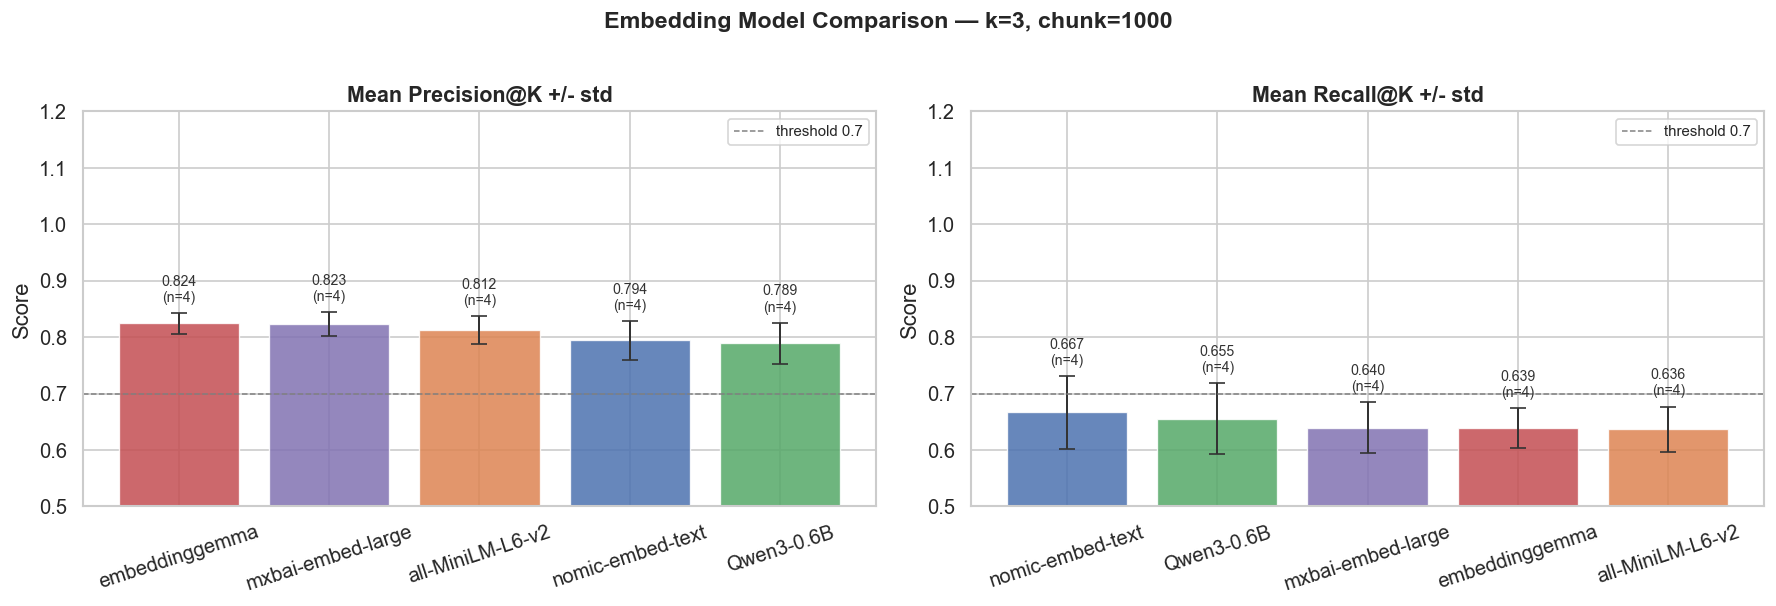

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (col_mean, col_std), label in zip(
    axes,
    [('precision_mean','precision_std'), ('recall_mean','recall_std')],
    ['Precision@K', 'Recall@K']
):
    s = summary.sort_values(col_mean, ascending=False)
    colors = [PALETTE.get(m, '#888') for m in s['model']]
    bars = ax.bar(
        s['model'], s[col_mean],
        yerr=s[col_std].fillna(0),
        color=colors, capsize=5, alpha=0.85,
        edgecolor='white', linewidth=0.8,
        error_kw=dict(ecolor='#333', elinewidth=1.2)
    )
    for bar, val, std, n in zip(bars, s[col_mean], s[col_std].fillna(0), s['runs']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + 0.015,
            f'{val:.3f}\n(n={n})',
            ha='center', va='bottom', fontsize=8.5, color='#333'
        )
    ax.axhline(0.7, color='gray', linestyle='--', linewidth=0.9, label='threshold 0.7')
    ax.set_ylim(0.5, 1.2)
    ax.set_title(f'Mean {label} +/- std', fontsize=13, fontweight='bold')
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=18)
    ax.legend(fontsize=9)

plt.suptitle('Embedding Model Comparison; k=3, chunk=1000', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_1_mean_variance.png', bbox_inches='tight')
plt.show()

## 2 · All runs as dots — see spread per model

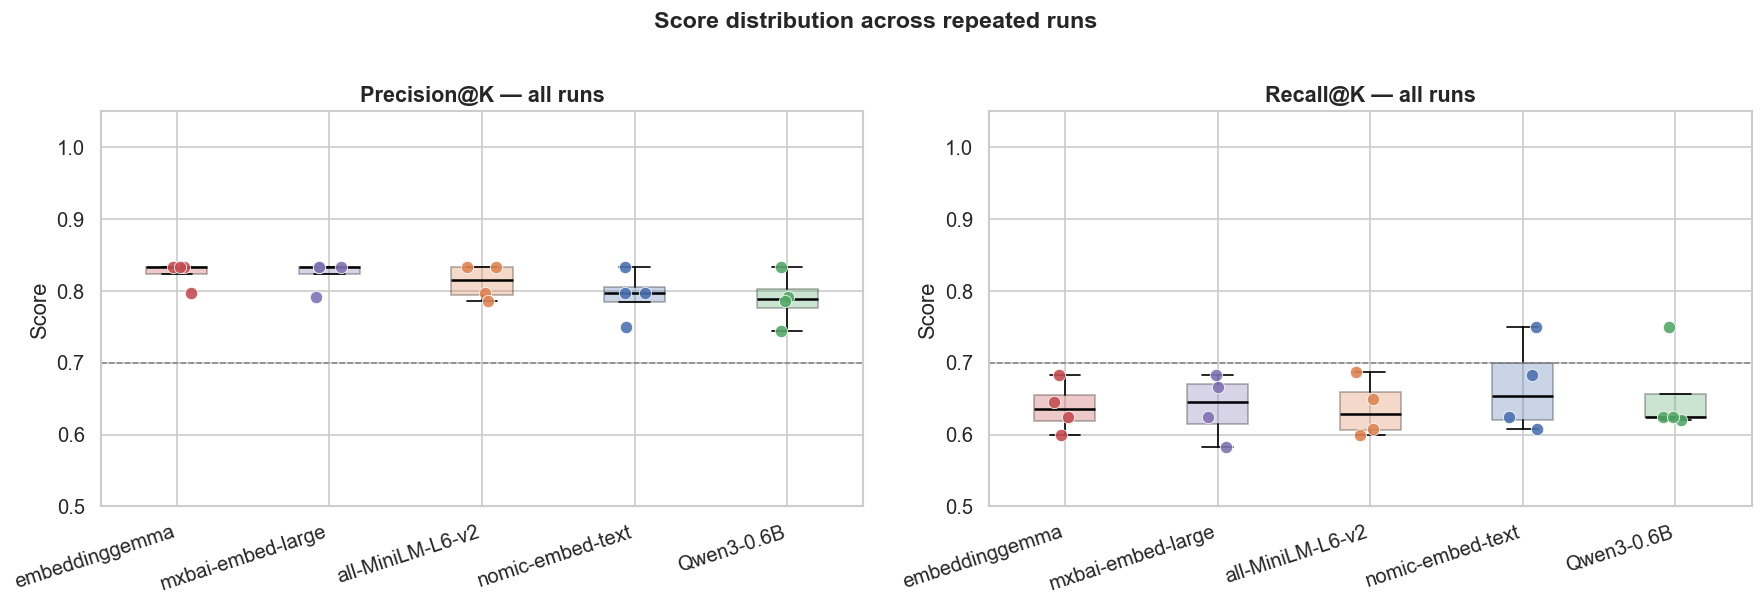

In [17]:
np.random.seed(42)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, metric, label in zip(
    axes, ['average_precision', 'average_recall'], ['Precision@K', 'Recall@K']
):
    data_by_model = [df[df['model'] == m][metric].values for m in model_order]

    bp = ax.boxplot(
        data_by_model, patch_artist=True, widths=0.4,
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(linewidth=1),
        capprops=dict(linewidth=1),
        flierprops=dict(marker='', alpha=0)
    )
    for patch, model in zip(bp['boxes'], model_order):
        patch.set_facecolor(PALETTE.get(model, '#888'))
        patch.set_alpha(0.3)

    for i, (model, vals) in enumerate(zip(model_order, data_by_model), start=1):
        jitter = np.random.uniform(-0.1, 0.1, size=len(vals))
        ax.scatter(
            np.full(len(vals), i) + jitter, vals,
            color=PALETTE.get(model, '#888'), s=55,
            zorder=5, alpha=0.9, edgecolors='white', linewidth=0.5
        )

    ax.axhline(0.7, color='gray', linestyle='--', linewidth=0.9)
    ax.set_xticks(range(1, len(model_order) + 1))
    ax.set_xticklabels(model_order, rotation=18, ha='right')
    ax.set_ylim(0.5, 1.05)
    ax.set_ylabel('Score')
    ax.set_title(f'{label} — all runs', fontsize=13, fontweight='bold')

plt.suptitle('Score distribution across repeated runs', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_2_spread.png', bbox_inches='tight')
plt.show()

## 3 · Heatmap — mean scores per model x query

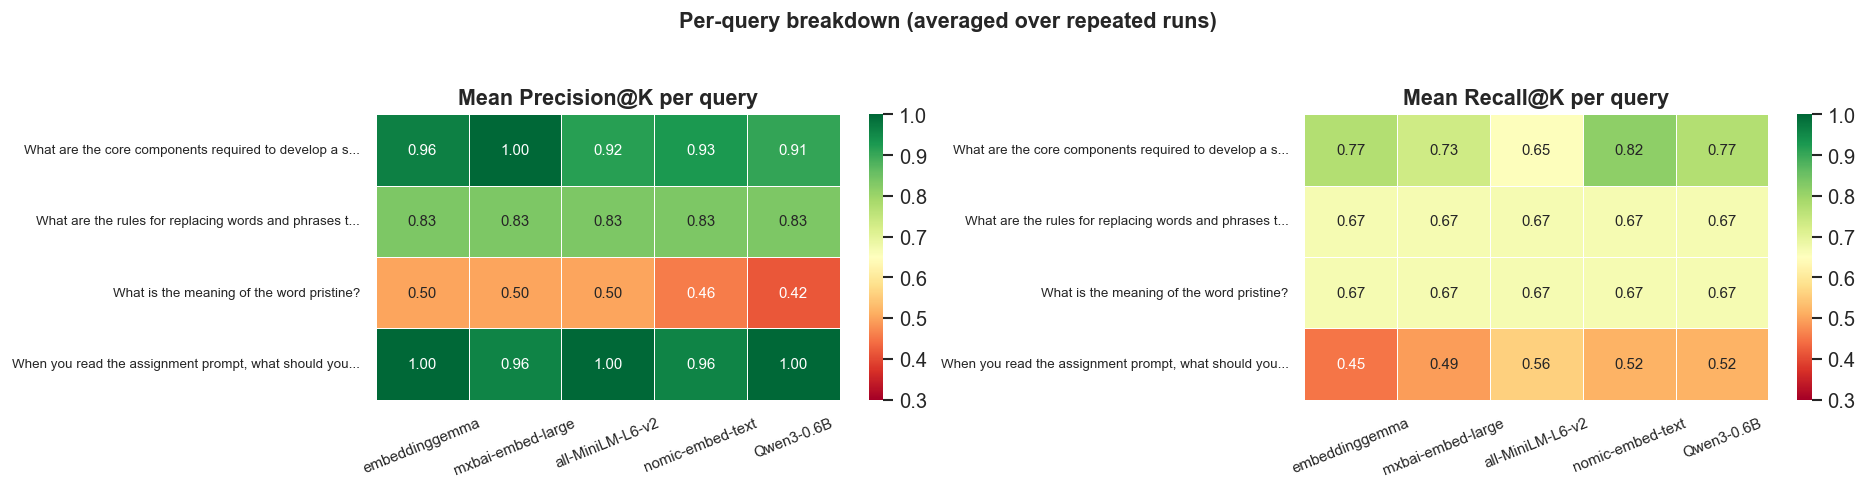

In [7]:
df_q_avg = df_q.groupby(['model', 'query']).agg(
    precision=('precision', 'mean'),
    recall=('recall', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, metric, label in zip(axes, ['precision', 'recall'], ['Precision@K', 'Recall@K']):
    pivot = df_q_avg.pivot(index='query', columns='model', values=metric)
    # reorder columns by mean precision
    cols = [m for m in model_order if m in pivot.columns]
    pivot = pivot[cols]

    sns.heatmap(
        pivot, ax=ax, annot=True, fmt='.2f',
        cmap='RdYlGn', vmin=0.3, vmax=1.0,
        linewidths=0.5, linecolor='white',
        annot_kws={'size': 9}
    )
    ax.set_title(f'Mean {label} per query', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=22, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.suptitle('Per-query breakdown (averaged over repeated runs)', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_3_heatmap.png', bbox_inches='tight')
plt.show()

# 4 Duration per model

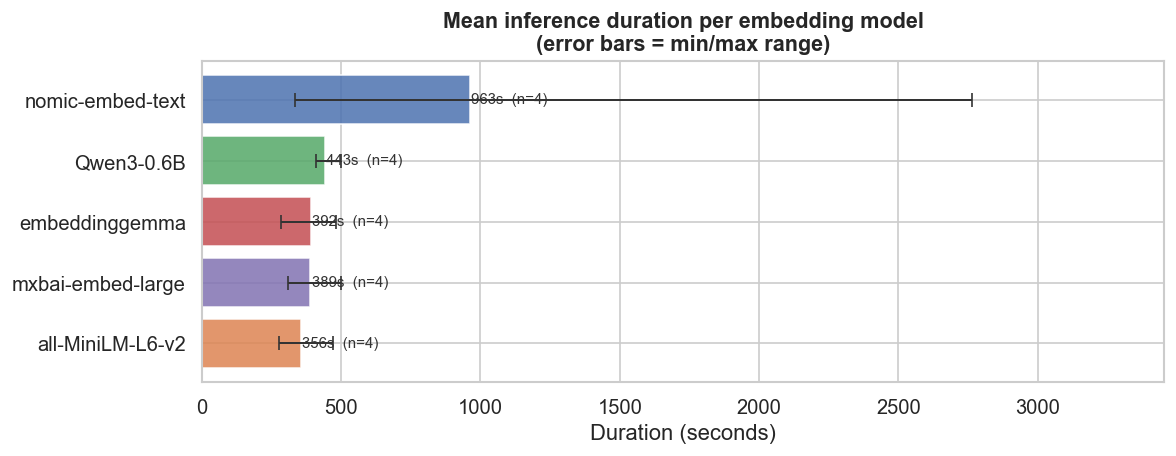

In [16]:
# ── Duration per model ────────────────────────────────────────────────────────
dur = df.groupby('model').agg(
    duration_mean = ('duration_seconds', 'mean'),
    duration_min  = ('duration_seconds', 'min'),
    duration_max  = ('duration_seconds', 'max'),
    runs          = ('duration_seconds', 'count'),
).reset_index().sort_values('duration_mean')

fig, ax = plt.subplots(figsize=(10, 4))
colors = [PALETTE.get(m, '#888') for m in dur['model']]
bars = ax.barh(
    dur['model'], dur['duration_mean'],
    color=colors, alpha=0.85, edgecolor='white'
)
# Error bars showing min/max range
ax.errorbar(
    dur['duration_mean'], range(len(dur)),
    xerr=[dur['duration_mean'] - dur['duration_min'],
          dur['duration_max'] - dur['duration_mean']],
    fmt='none', color='#333', capsize=4, linewidth=1.2
)
for bar, val, n in zip(bars, dur['duration_mean'], dur['runs']):
    ax.text(
        val + 5, bar.get_y() + bar.get_height() / 2,
        f'{val:.0f}s  (n={n})',
        va='center', fontsize=9, color='#333'
    )
ax.set_xlabel('Duration (seconds)')
ax.set_title('Mean inference duration per embedding model\n(error bars = min/max range)', fontsize=13, fontweight='bold')
ax.set_xlim(0, dur['duration_max'].max() * 1.25)
plt.tight_layout()
plt.savefig('chart_duration.png', bbox_inches='tight')
plt.show()

## 6 · Summary table

In [10]:
def ci95(std, n):
    if n < 2 or pd.isna(std):
        return 'n/a'
    margin = 1.96 * std / np.sqrt(n)
    return f'+/-{margin:.3f}'

table = summary.copy()
table['P CI95'] = table.apply(lambda r: ci95(r['precision_std'], r['runs']), axis=1)
table['R CI95'] = table.apply(lambda r: ci95(r['recall_std'],    r['runs']), axis=1)
table['P std']  = table['precision_std'].apply(lambda x: f'{x:.3f}' if pd.notna(x) else 'n/a')
table['R std']  = table['recall_std'].apply(lambda x: f'{x:.3f}' if pd.notna(x) else 'n/a')

out = table[['model','runs','precision_mean','P std','P CI95','recall_mean','R std','R CI95']].copy()
out.columns = ['Model','Runs','Precision','P Std','P CI95','Recall','R Std','R CI95']
out = out.reset_index(drop=True)
out.index += 1

out.style \
    .background_gradient(subset=['Precision','Recall'], cmap='RdYlGn', vmin=0.5, vmax=1.0) \
    .format({'Precision': '{:.4f}', 'Recall': '{:.4f}'})

,Model,Runs,Precision,P Std,P CI95,Recall,R Std,R CI95
1,embeddinggemma,4,0.8242,0.018,+/-0.018,0.6385,0.035,+/-0.035
2,mxbai-embed-large,4,0.8229,0.021,+/-0.020,0.6396,0.045,+/-0.044
3,all-MiniLM-L6-v2,4,0.8125,0.024,+/-0.024,0.6364,0.040,+/-0.040
4,nomic-embed-text,4,0.7943,0.034,+/-0.033,0.6666,0.064,+/-0.063
5,Qwen3-0.6B,4,0.7891,0.036,+/-0.035,0.6552,0.063,+/-0.062


## 7 · Findings

In [ ]:
best_p = summary.loc[summary['precision_mean'].idxmax()]
best_r = summary.loc[summary['recall_mean'].idxmax()]
most_stable = summary[summary['runs'] >= 2].loc[
    summary[summary['runs'] >= 2]['precision_std'].idxmin()
]

print('=== Summary ===')
print(f'Best Precision:  {best_p["model"]:25s}  {best_p["precision_mean"]:.4f}')
print(f'Best Recall:     {best_r["model"]:25s}  {best_r["recall_mean"]:.4f}')
print(f'Most stable:     {most_stable["model"]:25s}  std={most_stable["precision_std"]:.4f} (n={int(most_stable["runs"])})')
print()

q_avg_all = df_q.groupby('query')[['precision','recall']].mean()
weakest_q = q_avg_all['precision'].idxmin()
print(f'Hardest query across all models:')
print(f'  "{weakest_q}"')
print(f'  avg precision={q_avg_all.loc[weakest_q,"precision"]:.3f}  avg recall={q_avg_all.loc[weakest_q,"recall"]:.3f}')
print()
print('Note: the vocabulary lookup query (pristine) is consistently weak across all models.')
print('This is a chunking issue (boilerplate chunks from the vocabulary PDF), not a model issue.')
print('Filtering short/header chunks at ingestion time would improve this independently of model choice.')
print('The current recall is stuck around 0.62–0.67 across all models. The reason the judge gives is consistently "sentences 3–4 in the expected output not covered.Thats a chunking problem, the relevant text exists in the document but lands in a different chunk than what gets retrieved.')

=== Summary ===
Best Precision:  embeddinggemma             0.8242
Best Recall:     nomic-embed-text           0.6666
Most stable:     embeddinggemma             std=0.0182 (n=4)

Hardest query across all models:
  "What is the meaning of the word pristine?"
  avg precision=0.475  avg recall=0.667

Note: the vocabulary lookup query (pristine) is consistently weak across all models.
This is a chunking/ingestion issue (boilerplate chunks from the vocabulary PDF), not a model issue.
Filtering short/header chunks at ingestion time would improve this independently of model choice.
Your current recall is stuck around 0.62–0.67 across all models. The reason the judge gives is consistently "sentences 3–4 in the expected output not covered.Thats a chunking problem — the relevant text exists in the document but lands in a different chunk than what gets retrieved.


## 8 · Precision & Recall by model now grouped by chunk config

In [9]:
import pandas as pd
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

CUTOFF     = '2026-05-05'
KEEP_TOP_K = 3
JSONL_PATH = '../../reports/eval_retrieval_results.jsonl'

MODEL_LABELS = {
    'nomic-embed-text':                  'nomic',
    'nomic-embed-text:latest':           'nomic',
    'all-MiniLM-L6-v2':                 'all-MiniLM',
    'locusai/all-minilm-l6-v2:latest':  'all-MiniLM',
    'dengcao/Qwen3-Embedding-0.6B:Q8_0':'Qwen3-0.6B',
    'embeddinggemma:latest':             'embeddinggemma',
    'mxbai-embed-large:latest':          'mxbai-large',
}

PALETTE = {
    'nomic':          '#4C72B0',
    'all-MiniLM':     '#DD8452',
    'Qwen3-0.6B':     '#55A868',
    'embeddinggemma': '#C44E52',
    'mxbai-large':    '#8172B2',
}

CONFIGS     = [(1000, 200), (500, 100), (1000, 400)]
CONFIG_LABELS = {
    (1000, 200): 'Baseline (1000/200)',
    (500,  100): 'Config A (500/100)',
    (1000, 400): 'Config B (1000/400)',
}
CONFIG_COLORS = {
    (1000, 200): '#4C72B0',
    (500,  100): '#DD8452',
    (1000, 400): '#55A868',
}

print('Ready.')

Ready.


In [10]:
records = []
with open(JSONL_PATH, 'r') as f:
    raw = f.read()

chunks = re.split(r'}\s*{', raw)
for i, chunk in enumerate(chunks):
    if i > 0:
        chunk = '{' + chunk
    if i < len(chunks) - 1:
        chunk = chunk + '}'
    chunk = chunk.strip()
    if chunk:
        try:
            records.append(json.loads(chunk))
        except json.JSONDecodeError as e:
            print(f'Skipped: {chunk[:60]!r} — {e}')

df_raw = pd.DataFrame(records)
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])

df = df_raw[
    (df_raw['eval_type'] == 'retrieval') &
    (df_raw['timestamp'] >= CUTOFF) &
    (df_raw['top_k'] == KEEP_TOP_K) &
    (df_raw['average_precision'].notna())
].copy()

df['model']        = df['embedding_model'].map(MODEL_LABELS).fillna(df['embedding_model'])
df['config']       = list(zip(df['chunk_size'], df['chunk_overlap']))
df['config_label'] = df['config'].map(CONFIG_LABELS)

# Per-query rows
rows = []
for _, run in df.iterrows():
    for t in run['per_test']:
        rows.append({
            'model':        run['model'],
            'config':       run['config'],
            'config_label': run['config_label'],
            'query':        t['query'][:50] + '...' if len(t['query']) > 50 else t['query'],
            'precision':    t.get('precision'),
            'recall':       t.get('recall'),
            'hit':          int(t.get('document_hit', False)),
        })
df_q = pd.DataFrame(rows)

# Summary: mean per model x config
summary = df.groupby(['model', 'config', 'config_label']).agg(
    runs           = ('average_precision', 'count'),
    precision_mean = ('average_precision', 'mean'),
    precision_std  = ('average_precision', 'std'),
    recall_mean    = ('average_recall',    'mean'),
    recall_std     = ('average_recall',    'std'),
).reset_index()

# Model order by baseline precision descending
baseline_order = (
    summary[summary['config'] == (1000, 200)]
    .sort_values('precision_mean', ascending=False)['model'].tolist()
)

print(f'Loaded {len(df)} runs | {df["model"].nunique()} models | configs: {sorted(df["config"].unique().tolist())}')
print()
print(summary[['model','config_label','runs','precision_mean','recall_mean']].to_string(index=False))

Loaded 30 runs | 5 models | configs: [(500, 100), (1000, 200), (1000, 400)]

         model        config_label  runs  precision_mean  recall_mean
    Qwen3-0.6B  Config A (500/100)     1        0.875000     0.608300
    Qwen3-0.6B Baseline (1000/200)     4        0.789075     0.655200
    Qwen3-0.6B Config B (1000/400)     1        0.958300     0.666700
    all-MiniLM  Config A (500/100)     1        0.875000     0.645800
    all-MiniLM Baseline (1000/200)     4        0.812500     0.636450
    all-MiniLM Config B (1000/400)     1        0.938900     0.562500
embeddinggemma  Config A (500/100)     1        0.791700     0.645800
embeddinggemma Baseline (1000/200)     4        0.824200     0.638525
embeddinggemma Config B (1000/400)     1        0.958300     0.666700
   mxbai-large  Config A (500/100)     1        0.875000     0.604200
   mxbai-large Baseline (1000/200)     4        0.822900     0.639575
   mxbai-large Config B (1000/400)     1        1.000000     0.583300
         nomi

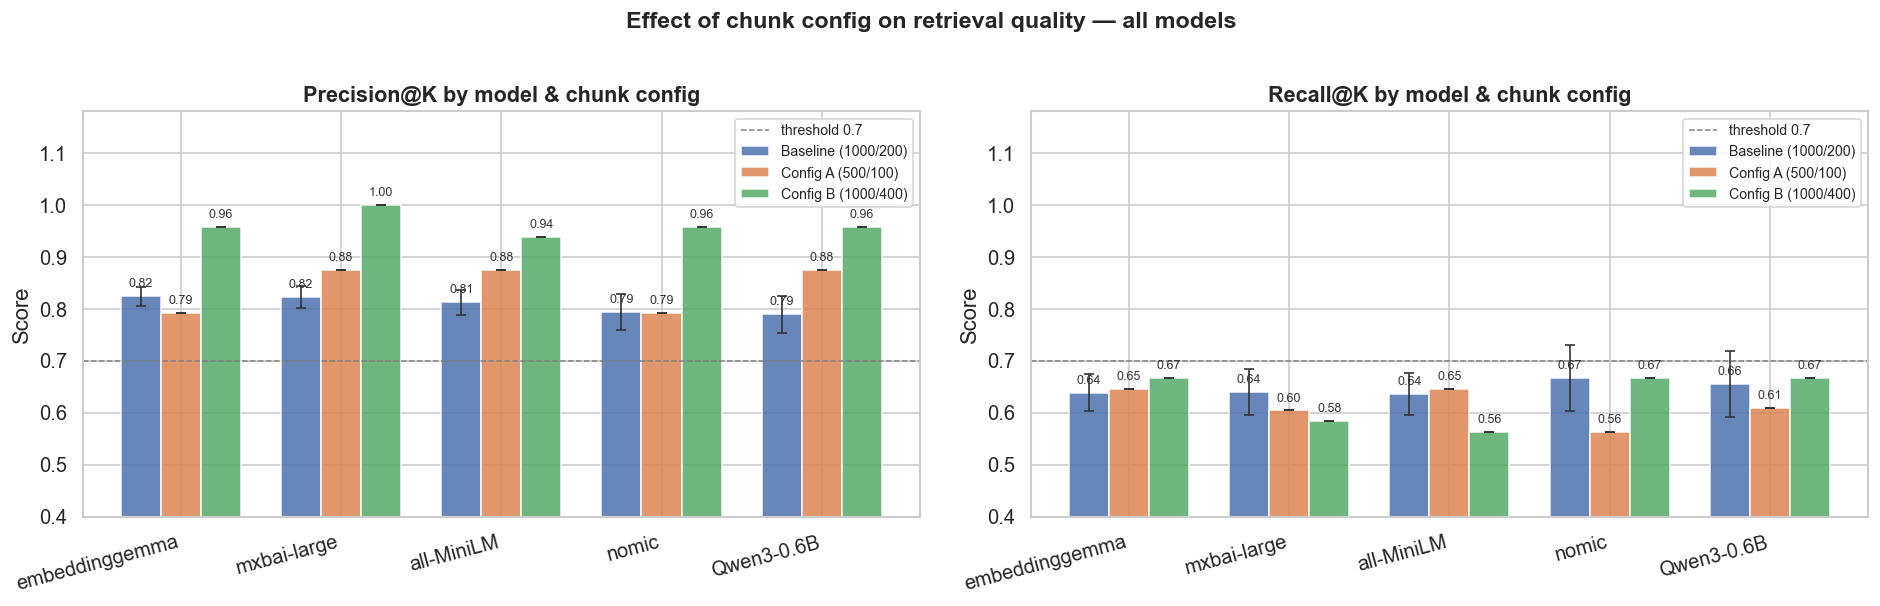

In [11]:
x     = np.arange(len(baseline_order))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, label in zip(axes, ['precision_mean', 'recall_mean'], ['Precision@K', 'Recall@K']):
    std_col = metric.replace('mean', 'std')
    for j, cfg in enumerate(CONFIGS):
        vals, errs = [], []
        for model in baseline_order:
            row = summary[(summary['model'] == model) & (summary['config'] == cfg)]
            if len(row):
                vals.append(row[metric].values[0])
                s = row[std_col].values[0]
                errs.append(s if pd.notna(s) else 0)
            else:
                vals.append(np.nan)
                errs.append(0)

        bars = ax.bar(
            x + j * width, vals, width,
            label=CONFIG_LABELS[cfg],
            color=CONFIG_COLORS[cfg], alpha=0.85,
            yerr=errs, capsize=3,
            error_kw=dict(elinewidth=1, ecolor='#333')
        )
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.012,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7.5, color='#333'
                )

    ax.set_xticks(x + width)
    ax.set_xticklabels(baseline_order, rotation=15, ha='right')
    ax.set_ylim(0.4, 1.18)
    ax.axhline(0.7, color='gray', linestyle='--', linewidth=0.9, label='threshold 0.7')
    ax.set_ylabel('Score')
    ax.set_title(f'{label} by model & chunk config', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8.5)

plt.suptitle('Effect of chunk config on retrieval quality — all models', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_1_config_comparison.png', bbox_inches='tight')
plt.show()

## 9 · Mean across all models per config

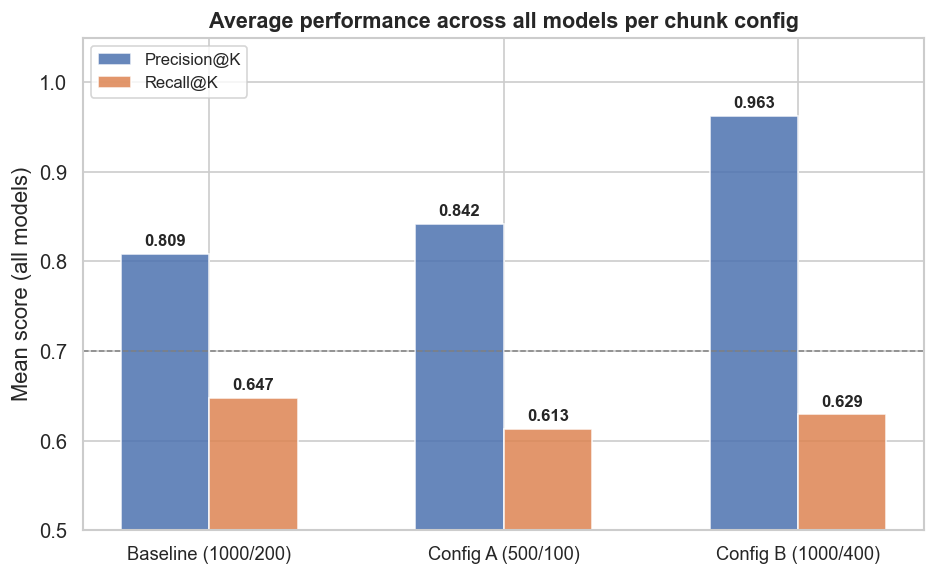

In [12]:
config_avg = summary.groupby('config_label').agg(
    precision=('precision_mean', 'mean'),
    recall   =('recall_mean',    'mean'),
).reset_index()

cfg_order = [CONFIG_LABELS[c] for c in CONFIGS]
config_avg['config_label'] = pd.Categorical(config_avg['config_label'], categories=cfg_order, ordered=True)
config_avg = config_avg.sort_values('config_label')

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(config_avg))
w = 0.3
b1 = ax.bar(x - w/2, config_avg['precision'], w, label='Precision@K', color='#4C72B0', alpha=0.85)
b2 = ax.bar(x + w/2, config_avg['recall'],    w, label='Recall@K',    color='#DD8452', alpha=0.85)

for bar in list(b1) + list(b2):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.006,
        f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_xticks(x)
ax.set_xticklabels(config_avg['config_label'], fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.axhline(0.7, color='gray', linestyle='--', linewidth=0.9)
ax.set_ylabel('Mean score (all models)')
ax.set_title('Average performance across all models per chunk config', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart_2_config_overall.png', bbox_inches='tight')
plt.show()

## Findings

In [ ]:
for _, row in config_avg.iterrows():
    label = str(row['config_label'])
    print(f'  {label:30s}  Precision={row["precision"]:.4f}  Recall={row["recall"]:.4f}')

print()
best = summary.copy()
best['combined'] = best['precision_mean'] * 0.4 + best['recall_mean'] * 0.6 
top = best.sort_values('combined', ascending=False).iloc[0]
print(f'Best single combination 60% recall and 40% precision:')
print(f'  Model:  {top["model"]}')
print(f'  Config: {top["config_label"]}')
print(f'  Precision={top["precision_mean"]:.4f}  Recall={top["recall_mean"]:.4f}')


  Baseline (1000/200)             Precision=0.8086  Recall=0.6473
  Config A (500/100)              Precision=0.8417  Recall=0.6133
  Config B (1000/400)             Precision=0.9628  Recall=0.6292

Best single combination:
  Model:  Qwen3-0.6B
  Config: Config B (1000/400)
  Precision=0.9583  Recall=0.6667


### Interpretation

Config A (500/100): smaller chunks improve precision ranking (more specific hits) but recall drops for multi-point concepts — less text per chunk means fewer sub-points covered.

Config B (1000/400): larger overlap bridges split concepts, best for recall. Precision also improves since the relevant chunk now contains more of the expected concept.

*From my understanding: Config B is likely the better production choice given recall matters more for feedback quality.*